In [20]:
import torch
from torchvision import transforms
from PIL import Image
import random
import albumentations as A
import csv
from typing import List, Tuple

def get_base_transform():
    """Get basic image transformation pipeline."""
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

def get_random_augmentation() -> A.Compose:
    """Create a random combination of augmentations."""
    possible_augmentations = [
        A.RandomBrightnessContrast(brightness_limit=(0, 1), p=0.5), #-1.5 to 1
        A.GaussianBlur(blur_limit=(1, 3), p=0.2), #3x3
        A.Perspective(scale=(0.03, 0.05), p=0.7, fit_output=True, pad_mode=1, pad_val=1, mask_pad_val=0, keep_size=True, interpolation=0), #0.03x0.05
        A.OpticalDistortion(distort_limit=(0, 0.1), p=0.8)
    ]
    
    num_augmentations = random.randint(1, 4)
    selected_augmentations = random.sample(possible_augmentations, num_augmentations)
    
    return A.Compose(selected_augmentations)

def process_image_with_augmentations(image: Image.Image, base_transform, num_augmented_copies: int) -> List[torch.Tensor]:
    """
    Process an image and create multiple augmented versions.
    Returns a list containing the original image and its augmented copies.
    """
    original_tensor = base_transform(image)
    images = [original_tensor]
    
    image_np = original_tensor.permute(1, 2, 0).numpy()
    
    for _ in range(num_augmented_copies):
        aug_pipeline = get_random_augmentation()
        augmented = aug_pipeline(image=image_np)
        aug_image = augmented['image']
        aug_tensor = torch.from_numpy(aug_image).permute(2, 0, 1)
        images.append(aug_tensor)
    
    return images

def prepare_augmented_dataset(image_paths: List[str], texts: List[str], num_augmented_copies: int) -> Tuple[List[Tuple[torch.Tensor, torch.Tensor, int]], dict]:
    """
    Prepare dataset with augmented copies.
    Returns a list of (image, text_tensor, text_length) tuples, including original and augmented versions.
    """
    unwrapped_texts = []
    for text in texts:
        with open(f'/kaggle/input/separated-journal/corresponding_text/{text}', newline='', encoding='utf-8') as csvfile:
            reader = csv.reader(csvfile)
            text = ''.join([''.join(row) for row in reader])
            unwrapped_texts.append(text)
    
    char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(set(''.join(unwrapped_texts))))}
    char_to_idx['<PAD>'] = 0
    
    base_transform = get_base_transform()
    expanded_dataset = []
    max_text_length = max(len(text) for text in unwrapped_texts)
    
    for image_path, text in zip(image_paths, unwrapped_texts):
        text_indices = [char_to_idx[c] for c in text]
        padded = text_indices + [char_to_idx['<PAD>']] * (max_text_length - len(text_indices))
        text_tensor = torch.tensor(padded)
        
        image = Image.open(f'/kaggle/input/full-resized-journal-scans/resized_journal_scans/{image_path}').convert('RGB')
        image_tensors = process_image_with_augmentations(image, base_transform, num_augmented_copies)
        
        for img_tensor in image_tensors:
            expanded_dataset.append((img_tensor, text_tensor, len(text)))
    
    return expanded_dataset, char_to_idx

In [21]:
import os
image_paths = os.listdir('/kaggle/input/full-resized-journal-scans/resized_journal_scans')
texts = os.listdir('/kaggle/input/separated-journal/corresponding_text')
dataset, char_to_idx = prepare_augmented_dataset(image_paths, texts, num_augmented_copies=5)
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

In [22]:
len(dataset)

360

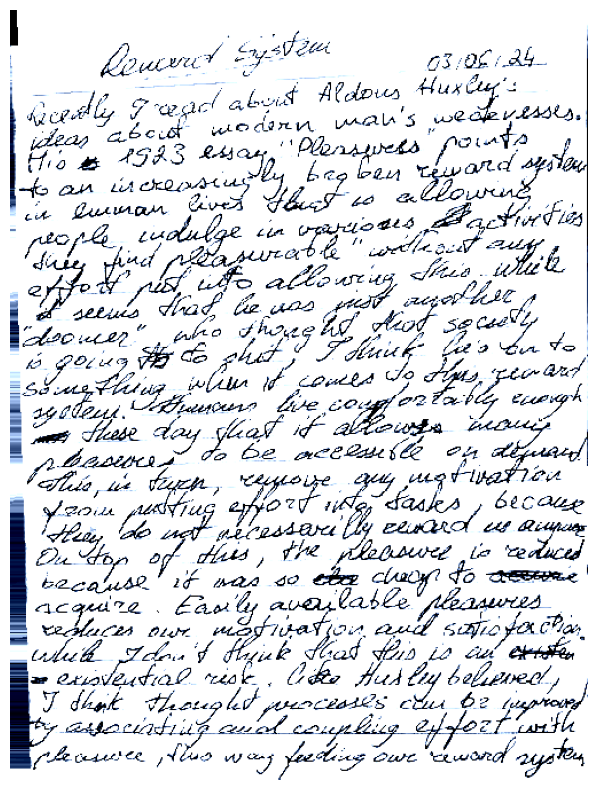

In [23]:
import matplotlib.pyplot as plt

example_image, text_indices, text_length = dataset[random.randint(0,len(dataset))]

plt.figure(figsize=(10, 10))
plt.imshow(example_image.permute(1, 2, 0), cmap='gray')
plt.axis('off')  # Hide the axis
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

train_dataset, val_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [35]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # Main path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Skip connection path (1x1 conv if dimensions change)
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        residual = self.skip(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out += residual
        out = self.relu(out)
        
        return out

class AttentionModule(nn.Module):
    def __init__(self, feature_dim, hidden_dim):
        super(AttentionModule, self).__init__()
        
        # Attention mechanism with two linear layers
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

class HandwritingRecognizer(nn.Module):
    def __init__(self, num_chars, hidden_size=64, num_lstm_layers=5, dropout_rate=0.5):
        super(HandwritingRecognizer, self).__init__()

        # Spatial dropout
        self.spatial_dropout = nn.Dropout2d(0.2)
        
        # Initial convolution layer
        self.initial_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Output: 32 x H/2 x W/2
        )
        
        # Residual blocks
        self.res_block1 = ResidualBlock(32, 64)
        self.pool1 = nn.MaxPool2d(2, 2)  # Output: 64 x H/4 x W/4
        
        self.res_block2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d((2, 1), (2, 1))  # Pool vertically only
        
        self.res_block3 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d((2, 1), (2, 1))  # Pool vertically only
        
        self.res_block4 = ResidualBlock(256, 512)
        self.pool4 = nn.MaxPool2d((2, 1), (2, 1))  # Pool vertically only

        self.res_block5 = ResidualBlock(512, 1024)
        self.pool5 = nn.MaxPool2d((2, 1), (2, 1))  # Pool vertically only
        
        self.dropout = nn.Dropout(dropout_rate)

        self.cnn_feature_size = 10240

        self.attention = AttentionModule(self.cnn_feature_size, hidden_size)
        self.feature_reduction = nn.Linear(self.cnn_feature_size, hidden_size * 2)
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=hidden_size * 2,
            hidden_size=hidden_size,
            num_layers=num_lstm_layers,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, num_chars)
        
    def forward(self, x):
        x = self.spatial_dropout(x)
        
        x = self.initial_conv(x)
        
        x = self.res_block1(x)
        x = self.pool1(x)
        
        x = self.res_block2(x)
        x = self.pool2(x)
        
        x = self.res_block3(x)
        x = self.pool3(x)
        
        x = self.res_block4(x)
        x = self.pool4(x)

        x = self.res_block5(x)
        features = self.pool5(x)
        
        # Reshape for LSTM
        b, c, h, w = features.size()
        features = features.permute(0, 3, 1, 2)
        features = features.reshape(b, w, c * h)
        
        features = self.dropout(features)

        #print(features.size())
        
        lstm_input = self.feature_reduction(features)
        
        # Apply LSTM with gradient checkpointing if training
        if self.training:
            lstm_out, _ = torch.utils.checkpoint.checkpoint(self.lstm, lstm_input)
        else:
            lstm_out, _ = self.lstm(lstm_input)

        lstm_out = self.layer_norm(lstm_out)
        lstm_out = self.dropout(lstm_out)
        outputs = self.fc(lstm_out)
        
        return outputs

In [9]:
class CTCLoss(nn.Module):
    def __init__(self, blank=0):
        super(CTCLoss, self).__init__()
        self.loss_fn = nn.CTCLoss(blank=blank, reduction='mean', zero_infinity=True)
        
    def forward(self, log_probs, targets, input_lengths, target_lengths):
        log_probs = log_probs.permute(1, 0, 2)
        return self.loss_fn(log_probs, targets, input_lengths, target_lengths)

In [10]:
# Fixed CTC Loss implementation
def compute_ctc_loss(outputs, targets, target_lengths, blank=0):
    """Compute CTC Loss with proper handling of input and target lengths"""
    batch_size = outputs.size(0)
    
    # Get sequence length (width) from output
    input_lengths = torch.full(size=(batch_size,), 
                              fill_value=outputs.size(1), 
                              dtype=torch.long,
                              device=outputs.device)
    
    # Apply log softmax to get log probabilities
    log_probs = F.log_softmax(outputs, dim=2)
    
    # Ensure targets are on the correct device and are long type
    targets = targets.to(outputs.device)
    target_lengths = target_lengths.to(outputs.device)
    
    # Transpose to time-major format as required by CTCLoss
    log_probs_T = log_probs.transpose(0, 1)  # [T, B, C]
    
    target_lengths = torch.clamp(target_lengths, max=log_probs.size(1)-1)

    # Ensure all values are valid for CTC
    for i in range(batch_size):
        if target_lengths[i] == 0:
            target_lengths[i] = 1
    
    # Print diagnostic information
    if torch.isnan(log_probs).any():
        print("Warning: NaN values in log_probs")
    
    # Compute CTC loss
    ctc_loss = nn.CTCLoss(blank=blank, reduction='mean', zero_infinity=True)
    try:
        loss = ctc_loss(log_probs_T, targets, input_lengths, target_lengths)
        
        # Check if loss is valid
        if torch.isnan(loss) or torch.isinf(loss):
            print("Invalid loss value:", loss.item())
            # Fallback to a custom implementation
            loss = 0
            for i in range(batch_size):
                valid_target = targets[i, :target_lengths[i]]
                valid_logprobs = log_probs[i, :input_lengths[i]]
                # Use a simple negative log likelihood as fallback
                pred_probs = torch.softmax(outputs[i], dim=1)
                for t, idx in enumerate(valid_target):
                    if t < valid_logprobs.size(0):
                        loss -= valid_logprobs[t, idx]
            loss = loss / batch_size
    except Exception as e:
        print(f"Error in CTC loss calculation: {e}")
        loss = torch.tensor(0.0, requires_grad=True, device=outputs.device)
    
    return loss

In [11]:
from collections import defaultdict

class TrainingMonitor:
    def __init__(self):
        self.history = defaultdict(list)
        
    def update(self, metrics):
        for k, v in metrics.items():
            self.history[k].append(v)
    
    def plot_learning_curves(self):
        plt.figure(figsize=(15, 5))
        
        # Plot training and validation loss
        plt.subplot(1, 2, 1)
        if 'train_loss' in self.history:
            plt.plot(self.history['train_loss'], label='Training Loss')
        if 'val_loss' in self.history:
            plt.plot(self.history['val_loss'], label='Validation Loss')
        plt.title('Loss vs. Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # Plot character error rate if available
        plt.subplot(1, 2, 2)
        if 'train_cer' in self.history:
            plt.plot(self.history['train_cer'], label='Training CER')
        if 'val_cer' in self.history:
            plt.plot(self.history['val_cer'], label='Validation CER')
        plt.title('Character Error Rate vs. Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('CER')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

        print('Best Training loss:', min(self.history['train_loss']))
        print('Best Validation loss:', min(self.history['val_loss']))
        print('Best Validation Charecter Error Rate:', min(self.history['val_cer']))

In [12]:
def calculate_cer(prediction, target):
    """Calculate character error rate using Levenshtein distance"""
    import Levenshtein
    return Levenshtein.distance(prediction, target) / len(target)

In [13]:
def validate(model, val_loader, criterion, device, idx_to_char):
    model.eval()
    total_loss = 0
    total_cer = 0
    num_batches = 0
    
    with torch.no_grad():
        for batch in val_loader:
            images, texts, text_lengths = batch
            images = images.to(device)
            texts = texts.to(device)
            text_lengths = text_lengths.to(device)
            
            outputs = model(images)

            loss = compute_ctc_loss(outputs, texts, text_lengths)

            pred_text = decode_prediction(outputs, idx_to_char)
            target_indices = texts[0, :text_lengths[0]].cpu().numpy()
            target_text = ''.join([idx_to_char[idx] for idx in target_indices if idx in idx_to_char])
            batch_cer = calculate_cer(pred_text, target_text)
            
            loss_value = loss.item()
            total_loss += loss_value
            total_cer += calculate_cer(pred_text, target_text)
            num_batches += 1
    
    return total_loss / max(num_batches, 1), total_cer / max(num_batches, 1)

In [ ]:
from tqdm import tqdm

def train_epoch(model, train_loader, criterion, optimizer, device, idx_to_char):
    model.train()
    total_loss = 0
    total_cer = 0
    num_batches = 0
    
    progress_bar = tqdm(train_loader, desc='Training')
    for batch in progress_bar:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        images, texts, text_lengths = batch
        batch_size = images.size(0)
        
        images = images.to(device)
        texts = texts.to(device)
        text_lengths = text_lengths.to(device)
        
        outputs = model(images)

        loss = compute_ctc_loss(outputs, texts, text_lengths)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        # Calculate CER
        pred_text = decode_prediction(outputs, idx_to_char)
        target_indices = texts[0, :text_lengths[0]].cpu().numpy()
        target_text = ''.join([idx_to_char[idx] for idx in target_indices if idx in idx_to_char])
        batch_cer = calculate_cer(pred_text, target_text)

        loss_value = loss.item()
        total_loss += loss.item()
        total_cer += batch_cer
        num_batches += 1
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss_value:.4f}',
            'cer': f'{batch_cer:.4f}'
        })
    
    return total_loss / max(num_batches, 1), total_cer / max(num_batches, 1)

In [50]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, idx_to_char, num_epochs, scheduler, patience):
    monitor = TrainingMonitor()
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        
        # Training
        model.train()
        train_loss, train_cer = train_epoch(model, train_loader, criterion, optimizer, device, idx_to_char)
        
        # Validation
        model.eval()
        val_loss, val_cer = validate(model, val_loader, criterion, device, idx_to_char)

        # Learning rate scheduling
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
        
        # Update monitor
        monitor.update({
            'train_loss': train_loss,
            'train_cer': train_cer,
            'val_loss': val_loss,
            'val_cer': val_cer
        })
        
        # Print epoch results
        print(f'Train Loss: {train_loss:.4f} | Train CER: {train_cer:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val CER: {val_cer:.4f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]:.6f}') 

        if patience_counter >= patience:
            print(f'Early stopping triggered after epoch {epoch+1}')
            break
        
    # Plot learning curves
    monitor.plot_learning_curves()
    
    return monitor

In [16]:
def decode_prediction(output, idx_to_char):
    pred_indices = torch.argmax(output, dim=2)
    pred_chars = []
    prev_char = None
    
    for idx in pred_indices[0]:
        char_idx = idx.item()
        if char_idx != 0 and char_idx != prev_char:
            if char_idx in idx_to_char:
                pred_chars.append(idx_to_char[char_idx])
        prev_char = char_idx
    
    return ''.join(pred_chars)

In [45]:
# Training setup function
def setup_training(model, learning_rate, weight_decay, patience):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay  # L2 regularization
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=patience,
        verbose=True
    )
    
    return optimizer, scheduler

In [18]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.2 MB/s eta 0:00:00:00:01



Epoch 1/100


Training: 100%|██████████| 18/18 [00:28<00:00,  1.60s/it, loss=1.7065, cer=0.9323]


Train Loss: 1.8218 | Train CER: 0.9295
Val Loss: 1.1901 | Val CER: 0.9990
Current LR: 0.001000

Epoch 2/100


Training: 100%|██████████| 18/18 [00:28<00:00,  1.61s/it, loss=1.4895, cer=0.9352]


Train Loss: 1.6713 | Train CER: 0.9269
Val Loss: 1.1816 | Val CER: 0.9990
Current LR: 0.001000

Epoch 3/100


...

Train Loss: 1.5057 | Train CER: 0.9930
Val Loss: 1.1226 | Val CER: 0.9967
Current LR: 0.000125

Epoch 60/100


Training: 100%|██████████| 18/18 [00:28<00:00,  1.58s/it, loss=1.5275, cer=0.9926]


Train Loss: 1.5057 | Train CER: 0.9924
Val Loss: 1.1227 | Val CER: 0.9967
Current LR: 0.000125

Epoch 61/100


Training: 100%|██████████| 18/18 [00:28<00:00,  1.58s/it, loss=1.3561, cer=0.9915]


Train Loss: 1.5045 | Train CER: 0.9929
Val Loss: 1.1224 | Val CER: 0.9967
Current LR: 0.000125
Early stopping triggered after epoch 61


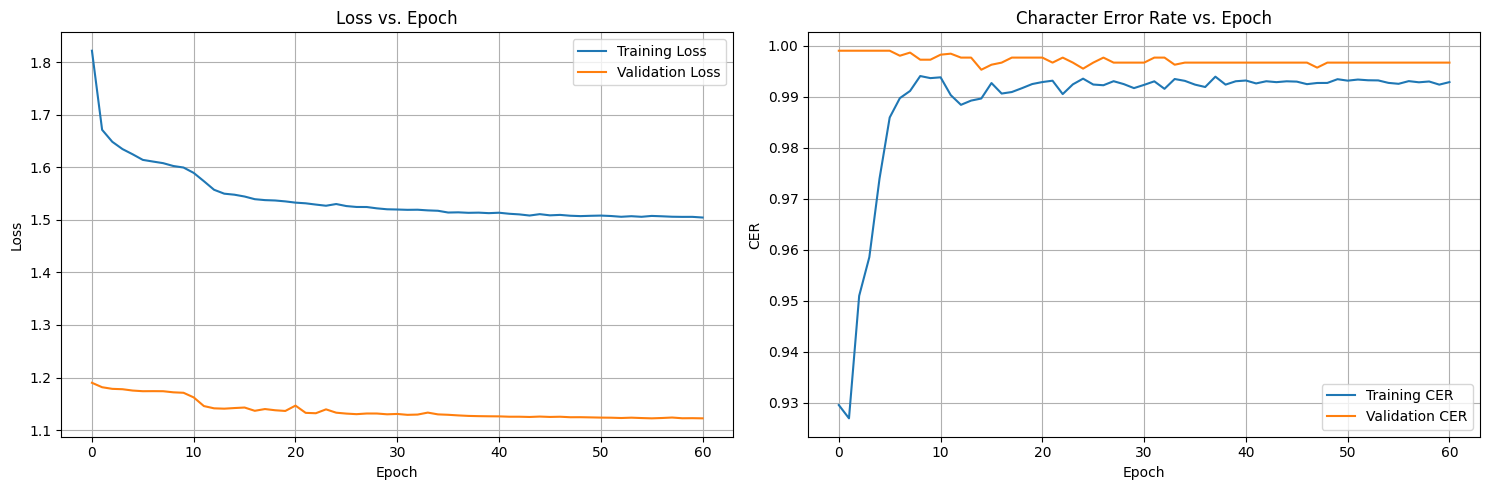

Best Training loss: 1.504455867740843
Best Validation loss: 1.1224249243736266
Best Validation Charecter Error Rate: 0.9952863044510032


In [51]:
from torch.utils.data import DataLoader

# Setup data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=16,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    pin_memory=True
)

# Initialize model and training components
model = HandwritingRecognizer(num_chars=len(char_to_idx))
optimizer, scheduler = setup_training(
    model,
    learning_rate=0.001,
    weight_decay=1e-3,  # Adjust this value if needed
    patience=2
)
criterion = CTCLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Train with monitoring
monitor = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    idx_to_char=idx_to_char,
    num_epochs=100,
    scheduler=scheduler,
    patience=5
)

In [52]:
model

HandwritingRecognizer(
  (spatial_dropout): Dropout2d(p=0.2, inplace=False)
  (initial_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res_block1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (skip): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, str